In [1]:
# Multi-Ticker BOS-Fib Scalping Research
#
# Runs NiftyBOSFibScalpStrategy on NSE equities, NIFTY index, and/or crypto.
# Data is loaded from local cache and fetched automatically if not present.
# Edit the Parameters cell below, then Run All.

In [2]:
from pathlib import Path
import sys

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src' / 'intraday_research').exists():
            return p
    raise FileNotFoundError('Cannot find repo root')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

REPO_ROOT

PosixPath('/home/rahul/trading2/trading_bot')

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython import get_ipython
from IPython.display import display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('load_ext', 'autoreload')
    ip.run_line_magic('autoreload', '2')

try:
    plt.style.use('seaborn-v0_8')
except OSError:
    plt.style.use('seaborn')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

from intraday_research.analytics import build_backtest_summary, hourly_summary, strategy_summary
from intraday_research.backtester import BacktestConfig, IntradayBacktester
from intraday_research.costs import TransactionCostModel
from intraday_research.features import FeatureEngine
from intraday_research.provider import MarketDataProvider
from intraday_research.risk import RiskManager
from intraday_research.strategies import NiftyBOSFibScalpStrategy
from intraday_research.types import InstrumentSpec

## Parameters

Edit `SYMBOLS_CONFIG` and settings below, then **Run All**.

In [4]:
# ── SYMBOLS ──────────────────────────────────────────────────────────────────
SYMBOLS_CONFIG = {
#     'RELIANCE':  'equity',
#     'HDFCBANK':  'equity',
#     'TCS':       'equity',
#     'SBIN':      'equity',
#     'ICICIBANK': 'equity',
    # 'NIFTY50': 'index',
#     'BTCUSDT': 'crypto',
    'ETHUSDT': 'crypto',
    'SOLUSDT': 'crypto',
}

START_DATE = '2026-07-22' #'2026-06-25' #'2026-01-01'
END_DATE   = '2026-07-29' #'2026-06-25'

# ── STRATEGY ──────────────────────────────────────────────────────────────────
ENTRY_MODE = 'limit_618'   # 'limit_618' or 'zone_touch_confirmation'

# ── PARAMETER SWEEP ───────────────────────────────────────────────────────────
IMPULSE_PCT_SWEEP = [0.25, 0.30] #, 0.50, 0.75, 1.00]   # % of median price
STOP_BUFFER_PCT   = 0.009
STOP_BUFFER_FLOOR = 0.05    # min stop cushion (lower for low-priced coins, e.g. 0.01 for SOL)

# ── REGIME FILTER (entry gate; skips setups whose regime condition fails) ──────
USE_REGIME_FILTER = False   # master switch
REGIME_USE_ER     = True   # Efficiency Ratio: require ER >= REGIME_ER_MIN
REGIME_ER_WINDOW  = 30
REGIME_ER_MIN     = 0.30
REGIME_USE_ADX    = False   # ADX: require ADX >= REGIME_ADX_MIN
REGIME_ADX_MIN    = 25
REGIME_USE_EMA    = True    # EMA-slope: LONG only if EMA rising, SHORT only if falling
REGIME_EMA_SPAN   = 44
# (filters combine with AND — every enabled one must pass)

# ── LOOKBACK (removes whole-period forward bias) ──────────────────────────────
# Reference median that scales min_impulse/stop is computed from the trailing
# LOOKBACK_DAYS trade_dates, FROZEN per day — NOT the whole backtest window.
LOOKBACK_DAYS     = 7

# ── SQUARE-OFF / SESSION policy ───────────────────────────────────────────────
#   dt_time(15, 30) → hard square-off daily at that IST time (NSE/BSE)   [default]
#   None            → 24h continuous, NO square-off (crypto — matches live)
from datetime import time as dt_time
# SQUARE_OFF  = dt_time(15, 30)   # NSE/BSE close (equity default — re-enable for NSE runs)
SQUARE_OFF    = None              # 24h continuous — crypto sweep matches the live bot
SESSION_START = dt_time(9, 15)    # NSE/BSE open (only used when SQUARE_OFF is a time)

# ── ENTRY FILL MODEL ──────────────────────────────────────────────────────────
#   int  → realistic: resting limit at fib_618, fills on touch within N bars.
#   None → optimistic: fill every signal on the confirmation bar (legacy).
ENTRY_MAX_BARS_WAIT = 20          # max bars to wait for retest fill (per-signal routing overrides for breakout)

# ── ENTRY MODE: NEXT-BAR OPEN (breakout entry) ────────────────────────────────
#   False → per-signal fill routing handles breakout vs retest (USE_BOS_STRENGTH_FILTER=True)
#   True  → force ALL entries to fill at bar N+1 open (overrides per-signal routing)
ENTRY_NEXT_BAR_OPEN = True
TIME_EXIT_MIN=90

# ── BOS STRENGTH FILTER ───────────────────────────────────────────────────────
#   True  → strong BOS bar (close in top/bottom 40% of range) → enter at N+1 open (breakout)
#           weak BOS bar → wait for broken-structure retest with rejection wick
#   False → all signals use ENTRY_MODE / ENTRY_NEXT_BAR_OPEN (legacy)
USE_BOS_STRENGTH_FILTER  = False
BOS_STRENGTH_THRESHOLD   = 0.6   # (close-low)/(high-low) >= threshold → strong BOS bar
BOS_RETEST_MAX_BARS_WAIT = 20    # max bars to wait for retest rejection wick

# ── SAME-BAR ENTRY GUARD ──────────────────────────────────────────────────────
# When one candle both sets the impulse extreme AND triggers the fib-618 pullback
# (degenerate momentum bar), require it to have OPENED near that extreme (genuine
# intrabar pullback / pin-bar). False = take all (current). True = filter these out.
SAME_BAR_OPEN_GUARD          = False
SAME_BAR_OPEN_POS_THRESHOLD  = 0.9

#   1.000 → target AT the BOS level                 RR varies (entry is at breakout, not fib)
#   1.272 → 127.2% Fib extension beyond BOS level
#   1.618 → 161.8% Fib extension beyond BOS level
TARGET_EXT_SWEEP  = [1.0, 1.272, 1.618]

# ── TRAILING STOP ─────────────────────────────────────────────────────────────
# Two mutually-exclusive modes — enable ONE, disable the other:
#
#   milestone trail (current):
#     Stop ratchets to each Fib level as price reaches it (BOS → 1.000 → 1.272).
#     Last milestone triggers a 50% partial exit; remainder rides to the fixed target.
#
#   ATR Chandelier trail:
#     stop = run_up_high − CHANDELIER_ATR_MULT × ATR(14min), ratchets upward only.
#     Arms after CHANDELIER_AFTER_R × initial-risk profit, then optionally jumps to
#     breakeven. Volatility-adaptive: wider stop in high-ATR conditions, tighter in
#     low-ATR. Fixed Fib target still applies — whichever exits first wins.
#     Uses the same 14-period ATR the FeatureEngine already adds to featured bars.
USE_TRAILING_STOP    = True    # milestone trail (BOS → 1.000 → 1.272 → partial exit)
USE_CHANDELIER_TRAIL = False   # ATR Chandelier trail — set True & above False to switch
CHANDELIER_ATR_MULT  = 2.0    # N×ATR behind the run-up high (wider = more room to breathe)
CHANDELIER_AFTER_R   = 1.0    # arm after 1× initial-risk profit
CHANDELIER_BREAKEVEN = True    # jump stop to entry price when chandelier first arms

# ── TRADE SIZING ──────────────────────────────────────────────────────────────
# Equity: integer shares (NSE does not support fractional shares)
EQUITY_TRADE_VALUE_INR = 500_000   # auto-compute shares: floor(value / median_price)
EQUITY_FIXED_QTY       = 1
INDEX_LOTS             = 1

# Crypto: fractional units supported — qty = value / median_price (float)
# e.g. BTC @ $72,764  →  5000 / 72764 = 0.0687 BTC  (NOT forced to 1.0)
CRYPTO_TRADE_VALUE_USD = 5_000
CRYPTO_QTY             = 1.0      # fallback if CRYPTO_TRADE_VALUE_USD is None

# ── PARALLELISATION ───────────────────────────────────────────────────────────
import os
N_WORKERS = max(1, min(os.cpu_count() - 1, 8))   # leave one core free for the kernel

# ── FYERS AUTH ────────────────────────────────────────────────────────────────
FYERS_AUTH_FILE = 'fyers_auth.json'
FYERS_USER_KEY  = 'user1'

# ── COSTS ─────────────────────────────────────────────────────────────────────
from intraday_research.costs import EQUITY_COSTS, MEXC_ZERO_COSTS
# MEXC: marketable limit orders → 0% fee on ALL sides (maker rate applies).
#   Entry  = marketable limit at bar N+1 open → maker fee = 0%
#   Exits  = marketable limit order            → maker fee = 0%
#   Result: net_pnl == gross_pnl  (no cost deduction for crypto runs)

OUTPUT_DIR = REPO_ROOT / 'artifacts' / 'multi_ticker_fib'


## Load Data

Data is loaded from local cache. Missing ranges are auto-fetched.

In [5]:
provider = MarketDataProvider(
    repo_root=REPO_ROOT,
    fyers_auth_file=FYERS_AUTH_FILE,
    fyers_user_key=FYERS_USER_KEY,
    verbose=True,
)

market_datasets: dict[str, pd.DataFrame] = {}

for sym, asset_type in SYMBOLS_CONFIG.items():
    try:
        print(f'Loading {sym} ({asset_type}) ...', end=' ', flush=True)
        df = provider.load(sym, asset_type, START_DATE, END_DATE)
        market_datasets[sym] = df
        print(f'{len(df):,} bars  [{df["trade_date"].min()} → {df["trade_date"].max()}]')
    except Exception as e:
        print(f'FAILED — {e}')

print(f'\nReady: {len(market_datasets)}/{len(SYMBOLS_CONFIG)} symbols loaded.')

Loading ETHUSDT (crypto) ... [provider] ETHUSDT (crypto): fetching missing data from Binance …
  ETHUSDT: cache 2023-01-01 → 2026-07-28 (1,878,549 bars)
  ETHUSDT: API 2026-07-29 → 2026-07-29 ... 1,165 bars
  ETHUSDT: saved 1,879,714 bars → /home/rahul/trading2/trading_bot/data/binance/ETHUSDT_1m.parquet
11,520 bars  [2026-07-22 → 2026-07-29]
Loading SOLUSDT (crypto) ... [provider] SOLUSDT (crypto): fetching missing data from Binance …
  SOLUSDT: cache 2023-01-01 → 2026-07-28 (1,879,119 bars)
  SOLUSDT: API 2026-07-29 → 2026-07-29 ... 1,165 bars
  SOLUSDT: saved 1,880,284 bars → /home/rahul/trading2/trading_bot/data/binance/SOLUSDT_1m.parquet
11,520 bars  [2026-07-22 → 2026-07-29]

Ready: 2/2 symbols loaded.


## Run Backtests

In [6]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from datetime import time as dt_time

# ── Strategy variants ─────────────────────────────────────────────────────────
STRATEGY_VARIANTS = {
    'BASE':     (False, False),
    'VWAP':     (True,  False),
    'EMA':      (False, True),
    'VWAP_EMA': (True,  True),
}

# Equity: NSE intraday session
_EQUITY_FIRST_TRADE = pd.Timestamp('09:20').time()
_EQUITY_LAST_ENTRY  = pd.Timestamp('15:25').time()
_EQUITY_SESSION_END = dt_time(15, 30)

# Crypto: 24h session — no NSE restrictions
_CRYPTO_FIRST_TRADE = pd.Timestamp('00:00').time()
_CRYPTO_LAST_ENTRY  = pd.Timestamp('23:50').time()
_CRYPTO_SESSION_END = dt_time(23, 59)


def _resolve_quantity(df: pd.DataFrame, asset_type: str) -> float:
    if asset_type == 'index':
        return float(INDEX_LOTS)
    if asset_type == 'crypto':
        if CRYPTO_TRADE_VALUE_USD is not None:
            # Float division — 5000 / 72764 = 0.0687 BTC, not max(1, int(...))
            return round(CRYPTO_TRADE_VALUE_USD / float(df['close'].median()), 6)
        return float(CRYPTO_QTY)
    # Equity: integer shares only (NSE does not support fractional)
    if EQUITY_TRADE_VALUE_INR is not None:
        return float(max(1, int(EQUITY_TRADE_VALUE_INR / float(df['close'].median()))))
    return float(EQUITY_FIXED_QTY)


def _instrument_spec(asset_type: str) -> InstrumentSpec:
    if asset_type == 'index':
        return InstrumentSpec(quantity_mode='lots', lot_size=65, instrument_type='index')
    return InstrumentSpec(quantity_mode='units', lot_size=1, instrument_type='equity')


def _daily_ref_medians(df, lookback_days):
    """Reference median per trade_date = median of closes over the PREVIOUS
    `lookback_days` trade_dates (exclusive of the date itself). Lookahead-free;
    the first date falls back to its own closes."""
    import numpy as np
    by_date = {d: g['close'].to_numpy() for d, g in df.groupby('trade_date', sort=True)}
    dates = sorted(by_date)
    out = {}
    for i, d in enumerate(dates):
        prior = dates[max(0, i - lookback_days):i]
        pooled = np.concatenate([by_date[p] for p in prior]) if prior else by_date[d]
        out[str(d)] = float(np.median(pooled))
    return out


def _session_config(asset_type):
    """(first_trade, last_entry, session_end, continuous) for the run.
    Equities/index always use the NSE session. Crypto follows the SQUARE_OFF switch:
    a time -> hard square-off at that IST time; None -> 24h continuous (no square-off)."""
    if asset_type != 'crypto':
        return _EQUITY_FIRST_TRADE, _EQUITY_LAST_ENTRY, _EQUITY_SESSION_END, False
    if SQUARE_OFF is None:
        return dt_time(0, 0), dt_time(23, 59), dt_time(23, 59), True
    from datetime import datetime as _dt, timedelta as _td
    last_entry = (_dt(2000, 1, 1, SQUARE_OFF.hour, SQUARE_OFF.minute) - _td(minutes=5)).time()
    return SESSION_START, last_entry, SQUARE_OFF, False


# ── Pre-process data ONCE in main process ─────────────────────────────────────
# Crypto tz-conversion and ref-median computation are the same for every job
# of a given symbol. Do them once here; workers inherit the result via the
# initializer (one pickling per worker, not one per job).
_preprocessed_datasets: dict[str, pd.DataFrame] = {}
_sym_ref_meds: dict[str, dict] = {}

for _sym, _asset_type in SYMBOLS_CONFIG.items():
    if _sym not in market_datasets:
        continue
    _df = market_datasets[_sym].copy()
    _, _, _, _continuous = _session_config(_asset_type)
    if _continuous:
        _df['timestamp']  = _df['timestamp'].dt.tz_convert('UTC')
        _df['trade_date'] = _df['timestamp'].dt.date.astype(str)
    _preprocessed_datasets[_sym] = _df
    _sym_ref_meds[_sym] = _daily_ref_medians(_df, LOOKBACK_DAYS)

# ── Worker initializer: load preprocessed data ONCE per worker process ─────────
# Avoids pickling 252k-row DataFrames for EVERY job (one per job → one per worker).
_WORKER_DATASETS: dict = {}

def _worker_init(datasets: dict) -> None:
    global _WORKER_DATASETS
    _WORKER_DATASETS = datasets


def _regime_signal_filter(signals, featured):
    """Entry gate: drop signals whose regime condition fails. Causal (each metric
    uses only past bars). Enabled filters combine with AND. Used via the backtester's
    signal_filter hook — the strategy itself is untouched."""
    import numpy as np, pandas as pd
    from intraday_research.types import SignalSide
    lut = {}
    for sym, g in featured.groupby('symbol', sort=False):
        g = g.sort_values('timestamp').reset_index(drop=True)
        c, h, l = g['close'], g['high'], g['low']
        N = REGIME_ER_WINDOW
        er = c.diff(N).abs() / c.diff().abs().rolling(N).sum()
        up, dn = h.diff(), -l.diff()
        pDM = np.where((up > dn) & (up > 0), up, 0.0)
        mDM = np.where((dn > up) & (dn > 0), dn, 0.0)
        tr = pd.concat([h - l, (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
        a = 1 / 14
        atr = tr.ewm(alpha=a, adjust=False).mean()
        pDI = 100 * pd.Series(pDM).ewm(alpha=a, adjust=False).mean() / atr
        mDI = 100 * pd.Series(mDM).ewm(alpha=a, adjust=False).mean() / atr
        dx = 100 * (pDI - mDI).abs() / (pDI + mDI).replace(0, np.nan)
        adx = dx.ewm(alpha=a, adjust=False).mean()
        e = c.ewm(span=REGIME_EMA_SPAN, adjust=False).mean()
        rising = e > e.shift(1)
        for i, ts in enumerate(g['timestamp']):
            lut[(sym, ts)] = (er.iloc[i], adx.iloc[i], bool(rising.iloc[i]))
    kept, rej = [], []
    for sig in signals:
        ok, why = True, 'pass'
        m = lut.get((sig.symbol, sig.timestamp))
        if m is not None:
            e_r, a_dx, rising = m
            if REGIME_USE_ER and not (e_r >= REGIME_ER_MIN):
                ok, why = False, 'er'
            if ok and REGIME_USE_ADX and not (a_dx >= REGIME_ADX_MIN):
                ok, why = False, 'adx'
            if ok and REGIME_USE_EMA and (
                    (sig.side is SignalSide.LONG and not rising) or
                    (sig.side is SignalSide.SHORT and rising)):
                ok, why = False, 'ema'
        (kept if ok else rej).append(sig if ok else {
            'timestamp': sig.timestamp, 'symbol': sig.symbol,
            'strategy_name': getattr(sig, 'strategy_name', ''),
            'reason': 'regime_' + why, 'stage': 'regime_filter'})
    return kept, rej


def run_one(
    sym: str, asset_type: str,
    variant: str, use_vwap: bool, use_ema: bool,
    min_impulse_pct: float, target_ext: float,
    ref_med_by_date: dict,
) -> dict:
    market_data = _WORKER_DATASETS[sym]
    is_crypto = (asset_type == 'crypto')
    first_trade, last_entry, session_end, continuous = _session_config(asset_type)
    # market_data already preprocessed (timezone etc.) by the main process

    min_impulse_by_date = {d: round(m * min_impulse_pct / 100, 4) for d, m in ref_med_by_date.items()}
    stop_buffer_by_date = {d: round(max(m * STOP_BUFFER_PCT / 100, STOP_BUFFER_FLOOR), 4) for d, m in ref_med_by_date.items()}
    for d in sorted(ref_med_by_date)[:LOOKBACK_DAYS]:
        min_impulse_by_date[d] = float('inf')
    trading_dates = sorted(ref_med_by_date)[LOOKBACK_DAYS:]
    first_ref = ref_med_by_date[trading_dates[0]] if trading_dates else ref_med_by_date[sorted(ref_med_by_date)[0]]
    min_imp  = round(first_ref * min_impulse_pct / 100, 4)
    stop_buf = round(max(first_ref * STOP_BUFFER_PCT / 100, STOP_BUFFER_FLOOR), 4)
    if is_crypto and CRYPTO_TRADE_VALUE_USD is not None:
        quantity = round(CRYPTO_TRADE_VALUE_USD / first_ref, 6)
    else:
        quantity = _resolve_quantity(market_data, asset_type)
    data_sym = market_data['symbol'].iloc[0]
    time_exit_min = TIME_EXIT_MIN

    strategy = NiftyBOSFibScalpStrategy(
        name=f'BOS_FIB_{variant}',
        pivot_lookback=2, min_swing_points=2,
        fib_zone_low=0.50, fib_zone_high=0.618,
        stop_buffer_points=stop_buf, min_impulse_points=min_imp,
        max_hold_bars=15, max_trades_per_day=500,
        max_consecutive_losses_per_day=200,
        entry_mode=ENTRY_MODE, min_confirmation_rr=0.0,
        use_vwap_filter=use_vwap, use_ema_filter=use_ema,
        target_extension_ratio=target_ext,
        min_impulse_by_date=min_impulse_by_date,
        stop_buffer_by_date=stop_buffer_by_date,
        use_bos_strength_filter=USE_BOS_STRENGTH_FILTER,
        bos_strength_threshold=BOS_STRENGTH_THRESHOLD,
        bos_retest_max_bars_wait=BOS_RETEST_MAX_BARS_WAIT,
        same_bar_entry_needs_open_near_extreme=SAME_BAR_OPEN_GUARD,
        same_bar_open_pos_threshold=SAME_BAR_OPEN_POS_THRESHOLD,
    )

    cost_model = MEXC_ZERO_COSTS if is_crypto else EQUITY_COSTS
    engine = IntradayBacktester(
        strategies=[strategy], feature_engine=FeatureEngine(),
        risk_manager=RiskManager(max_positions=1, max_daily_loss=50_000, quantity_per_trade=quantity),
        cost_model=cost_model,
        signal_filter=_regime_signal_filter if USE_REGIME_FILTER else None,
    )

    # Crypto: capital_based recomputes qty = CRYPTO_TRADE_VALUE_USD / entry_price per trade,
    # keeping notional constant (~$5k) even when ETH drops from $3k to $1.5k.
    # Equity: fixed integer shares (NSE has no fractional shares).
    if is_crypto and CRYPTO_TRADE_VALUE_USD is not None:
        _sizing_mode = 'capital_based'
        _capital_per_trade = float(CRYPTO_TRADE_VALUE_USD)
    else:
        _sizing_mode = 'fixed'
        _capital_per_trade = None

    result = engine.run(
        market_data,
        BacktestConfig(
            output_dir=str(OUTPUT_DIR / sym / variant / f'imp{min_impulse_pct}_ext{target_ext}'),
            instrument_specs={data_sym: _instrument_spec(asset_type)},
            initial_capital=1_000_000, max_positions=1, max_daily_loss=50_000,
            quantity_per_trade=quantity,
            sizing_mode=_sizing_mode,
            capital_per_trade_amount=_capital_per_trade,
            first_trade_time=first_trade,
            last_entry_time=last_entry,
            session_end=session_end,
            time_exit_minutes=time_exit_min,
            force_square_off_minutes_before_close=1,
            use_trailing_stop=USE_TRAILING_STOP,
            use_chandelier_trail=USE_CHANDELIER_TRAIL,
            chandelier_atr_multiplier=CHANDELIER_ATR_MULT,
            chandelier_trail_after_R=CHANDELIER_AFTER_R,
            chandelier_breakeven=CHANDELIER_BREAKEVEN,
            continuous_session=continuous,
            entry_max_bars_wait=ENTRY_MAX_BARS_WAIT,
            entry_next_bar_open=ENTRY_NEXT_BAR_OPEN,
            bos_retest_max_bars_wait=BOS_RETEST_MAX_BARS_WAIT,
        ),
    )
    result['_sym']        = sym
    result['_variant']    = variant
    result['_asset_type'] = asset_type
    result['_min_imp']    = min_imp
    result['_imp_pct']    = min_impulse_pct
    result['_target_ext'] = target_ext
    result['_quantity']   = quantity
    return result


# ── Sizing summary ─────────────────────────────────────────────────────────────
for sym, asset_type in SYMBOLS_CONFIG.items():
    if sym not in _preprocessed_datasets:
        continue
    med      = float(_preprocessed_datasets[sym]['close'].median())
    qty      = _resolve_quantity(_preprocessed_datasets[sym], asset_type)
    currency = '$' if asset_type == 'crypto' else '₹'
    print(f'{sym:10s} ({asset_type})  median={currency}{med:>12,.2f}  qty={qty:.6g}  '
          f'notional≈{currency}{qty * med:,.0f}')

# ── Build job list (no DataFrame in args — loaded from worker global) ──────────
jobs = [
    (sym, asset_type, variant, use_vwap, use_ema, imp_pct, target_ext, _sym_ref_meds[sym])
    for sym, asset_type in SYMBOLS_CONFIG.items() if sym in _preprocessed_datasets
    for variant, (use_vwap, use_ema) in STRATEGY_VARIANTS.items()
    for imp_pct in IMPULSE_PCT_SWEEP
    for target_ext in TARGET_EXT_SWEEP
]
total = len(jobs)
trail_mode = 'chandelier' if USE_CHANDELIER_TRAIL else ('milestone' if USE_TRAILING_STOP else 'none')
print(f'\nTrail mode: {trail_mode}' +
      (f'  (ATR×{CHANDELIER_ATR_MULT}, after {CHANDELIER_AFTER_R}R, breakeven={CHANDELIER_BREAKEVEN})'
       if USE_CHANDELIER_TRAIL else ''))
print(f'Launching {total} runs on {N_WORKERS} workers …\n')

# ── Parallel execution ─────────────────────────────────────────────────────────
results: dict[str, dict[str, dict[float, dict[float, dict]]]] = {}
done = 0

with ProcessPoolExecutor(
    max_workers=N_WORKERS,
    initializer=_worker_init,
    initargs=(_preprocessed_datasets,),
) as executor:
    futures = {executor.submit(run_one, *j): j for j in jobs}
    for future in as_completed(futures):
        try:
            r = future.result()
            r['_market_data'] = _preprocessed_datasets[r['_sym']]
            (results
             .setdefault(r['_sym'], {})
             .setdefault(r['_variant'], {})
             .setdefault(r['_imp_pct'], {})[r['_target_ext']]) = r
            s = build_backtest_summary(r['trades'], r['daily_pnl'])
            done += 1
            currency = '$' if r['_asset_type'] == 'crypto' else '₹'
            print(
                f'[{done:3d}/{total}] {r["_sym"]:8s} {r["_variant"]:8s} '
                f'imp={r["_imp_pct"]:.2f}% ext={r["_target_ext"]:.3f}  '
                f'qty={r["_quantity"]:.4g}  '
                f'tr={s["total_trades"]:3d} win={s["win_rate"]:.0f}%  '
                f'PF={s["profit_factor"]:.2f}  gross={currency}{s["gross_pnl"]:,.0f}'
            )
        except Exception as exc:
            j = futures[future]
            done += 1
            print(f'[{done:3d}/{total}] ERROR {j[0]} {j[2]} imp={j[5]} ext={j[6]}: {exc}')

print(f'\nDone — {done}/{total} runs.')


ETHUSDT    (crypto)  median=$    1,903.82  qty=2.62629  notional≈$5,000
SOLUSDT    (crypto)  median=$       75.24  qty=66.454  notional≈$5,000

Trail mode: milestone
Launching 48 runs on 7 workers …

[  1/48] ETHUSDT  BASE     imp=0.25% ext=1.000  qty=2.627  tr= 37 win=65%  PF=0.84  gross=$-25
[  2/48] ETHUSDT  BASE     imp=0.25% ext=1.272  qty=2.627  tr= 29 win=55%  PF=1.03  gross=$5
[  3/48] ETHUSDT  BASE     imp=0.25% ext=1.618  qty=2.627  tr= 27 win=52%  PF=1.16  gross=$24
[  4/48] ETHUSDT  BASE     imp=0.30% ext=1.272  qty=2.627  tr= 20 win=50%  PF=0.63  gross=$-54
[  5/48] ETHUSDT  BASE     imp=0.30% ext=1.000  qty=2.627  tr= 24 win=58%  PF=0.49  gross=$-74
[  6/48] ETHUSDT  BASE     imp=0.30% ext=1.618  qty=2.627  tr= 19 win=47%  PF=0.77  gross=$-34
[  7/48] ETHUSDT  VWAP     imp=0.25% ext=1.000  qty=2.627  tr= 29 win=69%  PF=1.03  gross=$3
[  8/48] ETHUSDT  VWAP     imp=0.25% ext=1.272  qty=2.627  tr= 23 win=61%  PF=1.28  gross=$33
[  9/48] ETHUSDT  VWAP     imp=0.30% ext=1.000

## Comparison Table

In [7]:
rows = []
for sym, variants in results.items():
    for variant, imps in variants.items():
        for imp_pct, exts in imps.items():
            for target_ext, r in exts.items():
                t = r['trades']
                s = build_backtest_summary(t, r['daily_pnl'])
                stops     = int((t['exit_reason'] == 'stop_loss').sum())        if not t.empty else 0
                trails    = int((t['exit_reason'] == 'trail_stop').sum())       if not t.empty else 0
                partials  = int((t['exit_reason'] == 'partial_target').sum())   if not t.empty else 0
                tgts      = int((t['exit_reason'] == 'target').sum())           if not t.empty else 0
                timeex    = int((t['exit_reason'] == 'time_exit').sum())        if not t.empty else 0
                forceex   = int((t['exit_reason'] == 'force_square_off').sum()) if not t.empty else 0
                rows.append(dict(
                    symbol=sym, variant=variant, imp_pct=f'{imp_pct:.2f}%',
                    ext=f'{target_ext:.3f}',
                    qty=r['_quantity'], min_imp_pts=r['_min_imp'],
                    signals=len(r['selected_strategy_signals']),
                    trades=s['total_trades'], win_pct=s['win_rate'],
                    gross=s['gross_pnl'], net=s['net_pnl'],
                    pf=s['profit_factor'], max_dd=s['max_drawdown'],
                    stops=stops, trail_stops=trails, partial_exits=partials,
                    tgts=tgts, time_exits=timeex, force_exits=forceex,
                ))

if rows:
    cmp = (pd.DataFrame(rows)
           .sort_values(['gross'], ascending=[False])
           .reset_index(drop=True))
    display(cmp.style.format({
        'min_imp_pts': '{:.2f}', 'gross': '{:,.0f}', 'net': '{:,.0f}',
        'max_dd': '{:,.0f}', 'win_pct': '{:.1f}%', 'pf': '{:.2f}',
    }))


,symbol,variant,imp_pct,ext,qty,min_imp_pts,signals,trades,win_pct,gross,net,pf,max_dd,stops,trail_stops,partial_exits,tgts,time_exits,force_exits
0,SOLUSDT,EMA,0.30%,1.618,65.928270,0.23,19,17,76.5%,110,110,3.02,-31,4,11,1,0,1,0
1,SOLUSDT,EMA,0.30%,1.272,65.928270,0.23,19,18,77.8%,102,102,2.86,-31,4,10,2,1,1,0
2,SOLUSDT,EMA,0.25%,1.618,65.928270,0.19,29,28,71.4%,101,101,1.91,-48,8,16,3,0,1,0
3,SOLUSDT,BASE,0.30%,1.618,65.928270,0.23,25,19,68.4%,95,95,2.27,-25,4,11,1,0,3,0
4,SOLUSDT,EMA,0.30%,1.000,65.928270,0.23,19,27,85.2%,89,89,2.63,-31,4,9,11,2,1,0
5,SOLUSDT,VWAP_EMA,0.30%,1.618,65.928270,0.23,14,12,75.0%,87,87,2.96,-31,3,8,1,0,0,0
6,SOLUSDT,BASE,0.30%,1.272,65.928270,0.23,25,20,70.0%,87,87,2.16,-25,4,10,2,1,3,0
7,SOLUSDT,EMA,0.25%,1.272,65.928270,0.19,29,31,74.2%,83,83,1.74,-48,8,13,6,3,1,0
8,SOLUSDT,VWAP_EMA,0.30%,1.272,65.928270,0.23,14,12,75.0%,78,78,2.77,-31,3,7,1,1,0,0
9,SOLUSDT,BASE,0.25%,1.618,65.928270,0.19,37,30,63.3%,76,76,1.52,-72,9,16,2,0,3,0


## Monthly PnL & Risk Metrics

**Monthly PnL table** — net P&L per calendar month per setup. Shows consistency (how many months are profitable).

**Risk Metrics** — Sharpe/Sortino annualized. Key columns:
- `sharpe` / `sortino` — annualized (√252). Dark green ≥ 1.5, light green ≥ 1.0, yellow ≥ 0.5, red < 0.5.
- `expectancy` — avg net PnL per trade (the "edge" per trade in ₹)
- `rr_ratio` — avg_win / |avg_loss| (reward-to-risk)
- `max_consec_w/l` — longest winning / losing streak
- `best_day` / `worst_day` — single-day peak PnL and max drawdown day

In [8]:

import numpy as np
from itertools import groupby as _groupby

TRADING_DAYS_PER_YEAR = 252


def _flatten():
    """Yield (sym, variant, imp_pct, target_ext, r) for every run."""
    for sym, variants in results.items():
        for variant, imps in variants.items():
            for imp_pct, exts in imps.items():
                for target_ext, r in exts.items():
                    yield sym, variant, imp_pct, target_ext, r


def _consec_streaks(pnl_arr):
    flags = [1 if v > 0 else 0 for v in pnl_arr]
    max_w = max((sum(1 for _ in g) for k, g in _groupby(flags) if k == 1), default=0)
    max_l = max((sum(1 for _ in g) for k, g in _groupby(flags) if k == 0), default=0)
    return max_w, max_l


# ── Monthly PnL table ─────────────────────────────────────────────────────────
def _build_monthly_table():
    rows, all_months = [], set()
    for sym, variant, imp_pct, target_ext, r in _flatten():
        t = r['trades']
        if t.empty:
            continue
        t = t.copy()
        t['entry_time'] = pd.to_datetime(t['entry_time'])
        t['month'] = t['entry_time'].dt.to_period('M')
        monthly_net = t.groupby('month')['net_pnl'].sum()
        all_months.update(monthly_net.index.tolist())
        row = {'symbol': sym, 'variant': variant,
               'imp_pct': f'{imp_pct:.2f}%', 'ext': f'{target_ext:.3f}',
               'net_total': round(t['net_pnl'].sum(), 0)}
        for m, v in monthly_net.items():
            row[str(m)] = round(v, 0)
        rows.append(row)
    if not rows:
        return pd.DataFrame(), []
    months_sorted = sorted(all_months)
    mcols = [str(m) for m in months_sorted]
    df = pd.DataFrame(rows)
    for mc in mcols:
        if mc not in df.columns:
            df[mc] = 0.0
        df[mc] = df[mc].fillna(0.0)
    df['n_pos']    = (df[mcols] > 0).sum(axis=1)
    df['consist%'] = (df['n_pos'] / len(mcols) * 100).round(0).astype(int)
    return df.sort_values('net_total', ascending=False).reset_index(drop=True), mcols


monthly_df, month_cols = _build_monthly_table()

if not monthly_df.empty:
    def _cell_bg(val):
        if pd.isna(val) or val == 0: return ''
        return 'background-color: #c6efce' if val > 0 else 'background-color: #ffc7ce'

    def _net_style(val):
        return 'color: #375623; font-weight: bold' if val > 0 else 'color: #9c0006; font-weight: bold'

    display(monthly_df.style
        .applymap(_cell_bg, subset=month_cols)
        .applymap(_net_style, subset=['net_total'])
        .format({**{m: '{:,.0f}' for m in month_cols}, 'net_total': '{:,.0f}'})
        .set_caption(
            f'Monthly Net PnL  |  n_pos = profitable months out of {len(month_cols)}  '
            '|  consist% = % months profitable  |  green = profit  red = loss'))


# ── Risk metrics table ────────────────────────────────────────────────────────
def _build_risk_table():
    rows = []
    for sym, variant, imp_pct, target_ext, r in _flatten():
        t = r['trades']
        dp = r['daily_pnl']
        if t.empty:
            continue
        t = t.sort_values('entry_time').reset_index(drop=True)

        daily_net = dp['net_pnl'] if (not dp.empty and 'net_pnl' in dp.columns) else pd.Series(dtype=float)
        mean_d   = daily_net.mean() if len(daily_net) > 0 else 0.0
        std_d    = daily_net.std()  if len(daily_net) > 1 else np.nan
        neg_d    = daily_net[daily_net < 0]
        down_std = neg_d.std()      if len(neg_d)    > 1 else np.nan

        sharpe  = (mean_d / std_d)    * TRADING_DAYS_PER_YEAR**0.5 if (pd.notna(std_d)    and std_d    > 0) else 0.0
        sortino = (mean_d / down_std) * TRADING_DAYS_PER_YEAR**0.5 if (pd.notna(down_std) and down_std > 0) else 0.0

        wins   = t[t['net_pnl'] > 0]['net_pnl']
        losses = t[t['net_pnl'] < 0]['net_pnl']
        avg_win  = wins.mean()   if len(wins)   > 0 else 0.0
        avg_loss = losses.mean() if len(losses) > 0 else 0.0
        rr       = abs(avg_win / avg_loss) if avg_loss != 0 else 0.0

        max_w, max_l = _consec_streaks(t['net_pnl'].values)

        te = pd.to_datetime(t['entry_time'])
        tx = pd.to_datetime(t['exit_time'])
        avg_dur = (tx - te).dt.total_seconds().mean() / 60

        rows.append(dict(
            symbol=sym, variant=variant,
            imp_pct=f'{imp_pct:.2f}%', ext=f'{target_ext:.3f}',
            sharpe=round(sharpe, 2),
            sortino=round(sortino, 2),
            expectancy=round(t['net_pnl'].mean(), 0),
            avg_win=round(avg_win, 0),
            avg_loss=round(avg_loss, 0),
            rr_ratio=round(rr, 2),
            max_win=round(wins.max(), 0)    if len(wins)   > 0 else 0,
            max_loss=round(losses.min(), 0) if len(losses) > 0 else 0,
            max_consec_w=max_w,
            max_consec_l=max_l,
            best_day=round(daily_net.max(), 0)  if len(daily_net) > 0 else 0,
            worst_day=round(daily_net.min(), 0) if len(daily_net) > 0 else 0,
            avg_dur_min=round(avg_dur, 1),
            trading_days=len(daily_net),
        ))

    return pd.DataFrame(rows).sort_values('sharpe', ascending=False).reset_index(drop=True)


risk_df = _build_risk_table()

if not risk_df.empty:
    def _sharpe_bg(val):
        if val >= 1.5: return 'background-color: #375623; color: white; font-weight: bold'
        if val >= 1.0: return 'background-color: #c6efce; font-weight: bold'
        if val >= 0.5: return 'background-color: #ffeb9c'
        return 'background-color: #ffc7ce'

    def _sign_color(val):
        if val > 0: return 'color: #375623'
        if val < 0: return 'color: #9c0006'
        return ''

    money_cols = ['expectancy', 'avg_win', 'avg_loss', 'max_win', 'max_loss', 'best_day', 'worst_day']
    fmt_risk = {c: '{:,.0f}' for c in money_cols}
    fmt_risk.update({'sharpe': '{:.2f}', 'sortino': '{:.2f}', 'rr_ratio': '{:.2f}', 'avg_dur_min': '{:.1f}'})

    display(risk_df.style
        .applymap(_sharpe_bg, subset=['sharpe'])
        .applymap(_sign_color, subset=money_cols)
        .format(fmt_risk)
        .set_caption(
            'Risk Metrics — Sharpe/Sortino annualized (252 days)  |  '
            'expectancy = avg net PnL/trade  |  rr_ratio = avg_win / |avg_loss|  |  '
            'ext = target extension ratio'))


/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop time

,symbol,variant,imp_pct,ext,net_total,2026-07,n_pos,consist%
0,SOLUSDT,EMA,0.30%,1.618,110,110,1,100
1,SOLUSDT,EMA,0.30%,1.272,102,102,1,100
2,SOLUSDT,EMA,0.25%,1.618,101,101,1,100
3,SOLUSDT,BASE,0.30%,1.618,95,95,1,100
4,SOLUSDT,EMA,0.30%,1.000,89,89,1,100
5,SOLUSDT,BASE,0.30%,1.272,87,87,1,100
6,SOLUSDT,VWAP_EMA,0.30%,1.618,87,87,1,100
7,SOLUSDT,EMA,0.25%,1.272,83,83,1,100
8,SOLUSDT,VWAP_EMA,0.30%,1.272,78,78,1,100
9,SOLUSDT,BASE,0.25%,1.618,76,76,1,100


,symbol,variant,imp_pct,ext,sharpe,sortino,expectancy,avg_win,avg_loss,rr_ratio,max_win,max_loss,max_consec_w,max_consec_l,best_day,worst_day,avg_dur_min,trading_days
0,SOLUSDT,VWAP_EMA,0.30%,1.272,775.09,0.00,7,14,-15,0.92,38,-20,5,2,40,39,15.4,2
1,SOLUSDT,VWAP_EMA,0.30%,1.000,151.79,0.00,4,7,-15,0.49,19,-20,8,2,39,33,16.9,2
2,SOLUSDT,VWAP_EMA,0.30%,1.618,104.01,0.00,7,15,-15,0.99,38,-20,5,2,48,39,15.4,2
3,SOLUSDT,EMA,0.30%,1.618,37.19,0.00,6,13,-14,0.93,38,-20,4,2,72,38,19.8,2
4,SOLUSDT,EMA,0.30%,1.272,27.59,0.00,6,11,-14,0.82,38,-20,4,2,72,30,20.6,2
5,SOLUSDT,EMA,0.30%,1.000,24.09,0.00,3,6,-14,0.46,19,-20,8,2,65,24,19.4,2
6,SOLUSDT,VWAP,0.30%,1.618,20.90,0.00,3,15,-14,1.04,38,-25,4,2,37,11,24.2,2
7,ETHUSDT,VWAP,0.25%,1.272,19.94,0.00,1,11,-13,0.83,21,-36,6,3,26,7,12.3,2
8,ETHUSDT,BASE,0.25%,1.272,19.54,0.00,0,10,-12,0.84,18,-36,7,4,4,1,13.3,2
9,SOLUSDT,VWAP_EMA,0.25%,1.618,16.30,0.00,3,13,-15,0.87,40,-20,5,3,46,8,20.8,2


## Period Analysis — Which Config Won Each Month & Why

For each calendar month this shows:
- **Market regime** — price return % (bull/bear/ranging) and average intraday range % (volatility)
- **Winning config** — the (imp_pct × ext) combination with the highest average net PnL that month (averaged over BASE/VWAP/EMA/VWAP_EMA to reduce noise)
- **Possible reason** — auto-inferred from the regime data
- **Heatmap** — monthly PnL for every (imp_pct × ext) combination, BASE variant, so you can see exactly which periods each config was hot or cold

/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop time

Monthly Winner & Market Regime  (PnL averaged across all variants)

AvgDailyRange% = avg (day_high − day_low) / day_close, per trading day in the month
Vol = High/Low vs symbol's own median across months  (N/A = only 1 month in window)



/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  warnings.warn(
/home/rahul/trading2/wealth/env/lib/python3.9/site-packages/pandas/core/arrays/datetimes.py:1162: UserWarning: Converting to PeriodArray/Index representation will drop time

,Symbol,Month,Return%,AvgDailyRange%,Direction,Vol,Winner Config,Winner $,Worst Config,Worst $,Possible Reason
0,ETHUSDT,2026-07,-0.6%,3.14%,Ranging,N/A,imp=0.25% / ext=1.618,$12,imp=0.30% / ext=1.000,$-42,"sideways/choppy — both long & short BOS fire frequently, no dominant trend; ext=1.618 won → momentum followed through fully without premature reversal; imp=0.25% → low threshold, many signals, suits frequent smaller setups"
1,SOLUSDT,2026-07,-5.1%,2.94%,Bear,N/A,imp=0.30% / ext=1.618,$85,imp=0.25% / ext=1.000,$37,"strong downtrend — bearish impulse legs carry hard and far; ext=1.618 won → momentum followed through fully without premature reversal; imp=0.30% → low threshold, many signals, suits frequent smaller setups"



── How often each (imp_pct × ext) wins in each regime ──

  Bear  (1 symbol-month):
    0.30% / 1.618            1 win    100%  ████████████████████

  Ranging  (1 symbol-month):
    0.25% / 1.618            1 win    100%  ████████████████████



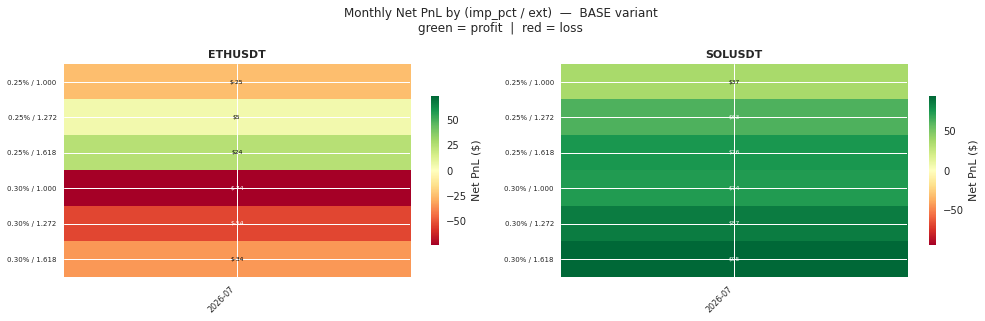

In [9]:
import numpy as np

# ── 1. Monthly market regime per symbol ──────────────────────────────────────
def _monthly_regime_df() -> pd.DataFrame:
    rows = []
    for sym, df in _preprocessed_datasets.items():
        df = df.copy()
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df['month'] = df['timestamp'].dt.to_period('M').astype(str)

        for month, grp in df.groupby('month'):
            # Aggregate to daily OHLC — proper daily range and monthly return
            by_date = grp.groupby('trade_date').agg(
                first_open=('open',  'first'),
                last_close=('close', 'last'),
                day_high=  ('high',  'max'),
                day_low=   ('low',   'min'),
            )
            if len(by_date) == 0:
                continue
            # Monthly return: first open → last close
            ret = (by_date['last_close'].iloc[-1] / by_date['first_open'].iloc[0] - 1) * 100
            # Daily range % = (day_high - day_low) / day_close × 100, averaged across days
            daily_rng = (by_date['day_high'] - by_date['day_low']) / by_date['last_close'] * 100
            avg_rng = daily_rng.mean()
            rows.append(dict(
                symbol=sym, month=month,
                return_pct=round(float(ret), 1),
                avg_daily_range_pct=round(float(avg_rng), 2),
                n_days=len(by_date),
            ))
    df_out = pd.DataFrame(rows)
    if df_out.empty:
        return df_out
    df_out['direction'] = df_out['return_pct'].apply(
        lambda r: 'Bull' if r > 5 else ('Bear' if r < -5 else 'Ranging'))
    # Vol: High/Low vs symbol's own median. With <2 months comparison is meaningless → N/A
    for sym in df_out['symbol'].unique():
        mask = df_out['symbol'] == sym
        if mask.sum() < 2:
            df_out.loc[mask, 'vol'] = 'N/A'
            continue
        med = df_out.loc[mask, 'avg_daily_range_pct'].median()
        df_out.loc[mask, 'vol'] = df_out.loc[mask, 'avg_daily_range_pct'].apply(
            lambda x: 'High' if x > med else 'Low')
    return df_out


# ── 2. Monthly PnL per (sym, variant, imp_pct, ext) ──────────────────────────
def _monthly_pnl_long() -> pd.DataFrame:
    rows = []
    for sym, variants in results.items():
        for variant, imps in variants.items():
            for imp_pct, exts in imps.items():
                for ext, r in exts.items():
                    t = r['trades']
                    if t.empty:
                        continue
                    t = t.copy()
                    t['month'] = pd.to_datetime(t['entry_time']).dt.to_period('M').astype(str)
                    for month, grp in t.groupby('month'):
                        rows.append(dict(
                            symbol=sym, variant=variant,
                            imp_pct=imp_pct, ext=ext,
                            month=month,
                            net_pnl=round(float(grp['net_pnl'].sum()), 2),
                            trades=len(grp),
                        ))
    return pd.DataFrame(rows)


# ── 3. Build tables ───────────────────────────────────────────────────────────
regime_df   = _monthly_regime_df()
monthly_pnl = _monthly_pnl_long()

if monthly_pnl.empty:
    print("No trade data yet — run a backtest first.")
else:
    # avg over variants (BASE/VWAP/EMA/VWAP_EMA) to reduce noise
    avg_cfg = (
        monthly_pnl
        .groupby(['symbol', 'month', 'imp_pct', 'ext'], as_index=False)['net_pnl']
        .mean()
    )
    winner_idx = avg_cfg.groupby(['symbol', 'month'])['net_pnl'].idxmax()
    loser_idx  = avg_cfg.groupby(['symbol', 'month'])['net_pnl'].idxmin()

    winners = avg_cfg.loc[winner_idx].rename(
        columns={'net_pnl': 'winner_pnl', 'imp_pct': 'win_imp', 'ext': 'win_ext'})
    losers = avg_cfg.loc[loser_idx][['symbol', 'month', 'imp_pct', 'ext', 'net_pnl']].rename(
        columns={'net_pnl': 'worst_pnl', 'imp_pct': 'worst_imp', 'ext': 'worst_ext'})

    summary = (
        winners
        .merge(losers,    on=['symbol', 'month'])
        .merge(regime_df, on=['symbol', 'month'], how='left')
        .sort_values(['symbol', 'month'])
        .reset_index(drop=True)
    )

    # ── 4. Auto-explain: describe what actually happened, don't predict ───────
    def _explain(row):
        parts = []
        direction = row.get('direction', '')
        vol       = row.get('vol', '')
        win_imp   = row.get('win_imp', 0)
        win_ext   = row.get('win_ext', 0)
        avg_rng   = row.get('avg_daily_range_pct', 0)

        # Market direction context
        if direction == 'Bull':
            parts.append('strong uptrend — longs dominate, directional momentum keeps running')
        elif direction == 'Bear':
            parts.append('strong downtrend — bearish impulse legs carry hard and far')
        else:
            parts.append('sideways/choppy — both long & short BOS fire frequently, no dominant trend')

        # Volatility context (only when we have ≥2 months to compare)
        if vol == 'High':
            parts.append(f'above-avg daily range ({avg_rng:.1f}%) → wide bars favour larger extensions')
        elif vol == 'Low':
            parts.append(f'below-avg daily range ({avg_rng:.1f}%) → tighter bars, extension target depends on follow-through')
        # vol == 'N/A' → omit (single-period window, no relative comparison possible)

        # Describe the actual winning extension (not predict from vol)
        if win_ext >= 1.618:
            parts.append('ext=1.618 won → momentum followed through fully without premature reversal')
        elif win_ext >= 1.272:
            parts.append('ext=1.272 won → balanced target, reward without needing full extension')
        else:
            parts.append('ext=1.000 won → tight objective suits short-lived moves / quick reversals at BOS')

        # Impulse threshold
        if win_imp <= 0.30:
            parts.append(f'imp={win_imp:.2f}% → low threshold, many signals, suits frequent smaller setups')
        elif win_imp >= 0.75:
            parts.append(f'imp={win_imp:.2f}% → high threshold, only large structural breaks qualify')
        else:
            parts.append(f'imp={win_imp:.2f}% → mid threshold')

        return '; '.join(parts)

    summary['reason']       = summary.apply(_explain, axis=1)
    summary['win_config']   = summary.apply(
        lambda r: f"imp={r.win_imp:.2f}% / ext={r.win_ext:.3f}", axis=1)
    summary['worst_config'] = summary.apply(
        lambda r: f"imp={r.worst_imp:.2f}% / ext={r.worst_ext:.3f}", axis=1)

    # ── 5. Display styled table ───────────────────────────────────────────────
    show_cols = ['symbol', 'month', 'return_pct', 'avg_daily_range_pct',
                 'direction', 'vol', 'win_config', 'winner_pnl',
                 'worst_config', 'worst_pnl', 'reason']
    disp = summary[show_cols].copy()
    disp.columns = ['Symbol', 'Month', 'Return%', 'AvgDailyRange%',
                    'Direction', 'Vol', 'Winner Config', 'Winner $',
                    'Worst Config', 'Worst $', 'Possible Reason']

    def _pnl_color(val):
        try:
            v = float(val)
            return 'color: #375623; font-weight:bold' if v > 0 else \
                   'color: #9c0006; font-weight:bold' if v < 0 else ''
        except (TypeError, ValueError):
            return ''

    def _dir_bg(val):
        return {'Bull':    'background-color: #c6efce',
                'Bear':    'background-color: #ffc7ce',
                'Ranging': 'background-color: #ffeb9c'}.get(str(val), '')

    def _vol_bg(val):
        if str(val) == 'High': return 'background-color: #dce6f1'
        if str(val) == 'Low':  return 'background-color: #f5f5f5'
        return ''  # N/A → no colour

    print("Monthly Winner & Market Regime  (PnL averaged across all variants)\n")
    print("AvgDailyRange% = avg (day_high − day_low) / day_close, per trading day in the month")
    print("Vol = High/Low vs symbol's own median across months  (N/A = only 1 month in window)\n")
    display(
        disp.style
        .applymap(_pnl_color, subset=['Return%', 'Winner $', 'Worst $'])
        .applymap(_dir_bg,    subset=['Direction'])
        .applymap(_vol_bg,    subset=['Vol'])
        .format({'Return%': '{:+.1f}%', 'AvgDailyRange%': '{:.2f}%',
                 'Winner $': '${:,.0f}', 'Worst $': '${:,.0f}'})
        .set_caption(
            'Winner Config = best (imp_pct × ext) that month, averaged over BASE/VWAP/EMA/VWAP_EMA  |  '
            'Bull > +5%  Bear < −5%  else Ranging'
        )
    )

    # ── 6. Regime × config cross-tab ─────────────────────────────────────────
    print("\n── How often each (imp_pct × ext) wins in each regime ──\n")
    summary['cfg_lbl'] = (
        summary['win_imp'].apply(lambda x: f'{x:.2f}%') + ' / ' +
        summary['win_ext'].apply(lambda x: f'{x:.3f}')
    )
    cross = (
        summary.groupby(['direction', 'cfg_lbl'])
        .size()
        .reset_index(name='wins')
        .sort_values(['direction', 'wins'], ascending=[True, False])
    )
    for direction, grp in cross.groupby('direction'):
        total = grp['wins'].sum()
        print(f"  {direction}  ({total} symbol-month{'s' if total != 1 else ''}):")
        for _, row in grp.head(6).iterrows():
            bar = '█' * int(row['wins'] / total * 20)
            pct = row['wins'] / total * 100
            print(f"    {row['cfg_lbl']:22s}  {row['wins']:2d} win{'s' if row['wins']!=1 else ' '}  {pct:4.0f}%  {bar}")
        print()

    # ── 7. Heatmap: months × (imp_pct × ext) per symbol  [BASE variant] ─────
    base_pnl = monthly_pnl[monthly_pnl['variant'] == 'BASE'].copy()

    if not base_pnl.empty:
        syms     = sorted(base_pnl['symbol'].unique())
        months   = sorted(base_pnl['month'].unique())
        imp_vals = sorted(base_pnl['imp_pct'].unique())
        ext_vals = sorted(base_pnl['ext'].unique())
        combos   = [(imp, ext) for imp in imp_vals for ext in ext_vals]
        clabels  = [f'{imp:.2f}% / {ext:.3f}' for imp, ext in combos]

        n_cols = len(syms)
        fig, axes = plt.subplots(
            1, n_cols,
            figsize=(7 * n_cols, 1.2 + 0.55 * len(combos)),
            squeeze=False,
        )
        fig.suptitle(
            'Monthly Net PnL by (imp_pct / ext)  —  BASE variant\n'
            'green = profit  |  red = loss',
            fontsize=12,
        )

        for col_i, sym in enumerate(syms):
            ax  = axes[0][col_i]
            sub = base_pnl[base_pnl['symbol'] == sym]

            mat = np.zeros((len(combos), len(months)))
            for mi, month in enumerate(months):
                for ci, (imp, ext) in enumerate(combos):
                    hit = sub[
                        (sub['imp_pct'] == imp) & (sub['ext'] == ext) & (sub['month'] == month)
                    ]
                    mat[ci, mi] = float(hit['net_pnl'].values[0]) if len(hit) else 0.0

            vmax = max(abs(mat).max(), 1.0)
            im = ax.imshow(mat, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

            ax.set_xticks(range(len(months)))
            ax.set_xticklabels(months, rotation=45, ha='right', fontsize=8)
            ax.set_yticks(range(len(combos)))
            ax.set_yticklabels(clabels, fontsize=7)
            ax.set_title(sym, fontsize=11, fontweight='bold')

            for ci in range(len(combos)):
                for mi in range(len(months)):
                    v = mat[ci, mi]
                    norm_v = float(im.norm(v))
                    txt_color = 'black' if 0.25 < norm_v < 0.75 else 'white'
                    ax.text(mi, ci, f'${v:,.0f}', ha='center', va='center',
                            fontsize=6, color=txt_color)

            plt.colorbar(im, ax=ax, shrink=0.7, label='Net PnL ($)')

        plt.tight_layout()
        plt.show()
    else:
        print("(No BASE-variant trades found — skipping heatmap)")


## Charts

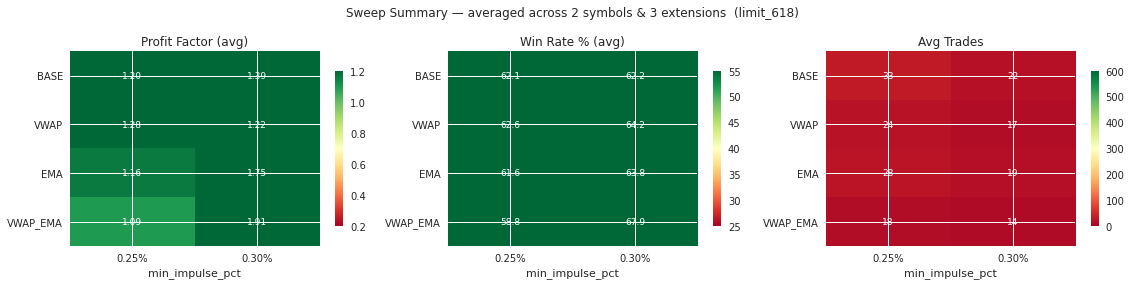

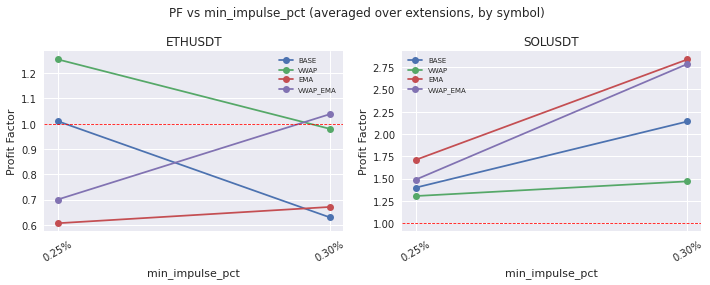

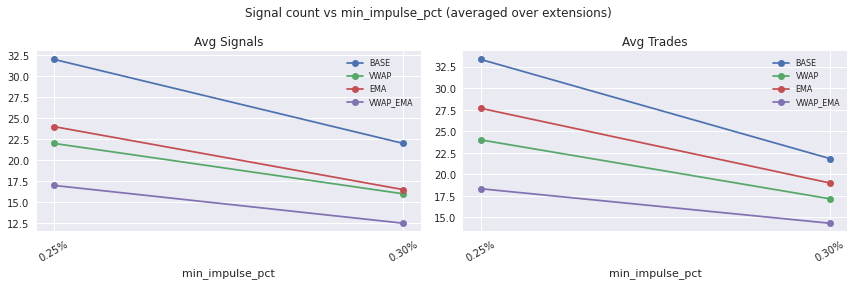

In [10]:
def _prep(r):
    t = r['trades'].copy()
    if t.empty: return t
    t['entry_time'] = pd.to_datetime(t['entry_time'])
    t['exit_time']  = pd.to_datetime(t['exit_time'])
    t = t.sort_values('entry_time').reset_index(drop=True)
    t['trade_number']  = range(1, len(t) + 1)
    t['cum_net_pnl']   = t['net_pnl'].cumsum()
    t['running_peak']  = t['cum_net_pnl'].cummax()
    t['drawdown']      = t['cum_net_pnl'] - t['running_peak']
    t['entry_hour']    = t['entry_time'].dt.strftime('%H:00')
    t['trade_date']    = t['entry_time'].dt.date
    return t


def _all_rows():
    """Flatten 4-level results dict into a DataFrame row per run."""
    rows = []
    for sym, variants in results.items():
        for variant, imps in variants.items():
            for imp_pct, exts in imps.items():
                for target_ext, r in exts.items():
                    s = build_backtest_summary(r['trades'], r['daily_pnl'])
                    rows.append(dict(sym=sym, variant=variant, imp_pct=imp_pct,
                                     target_ext=target_ext,
                                     pf=s['profit_factor'], win_pct=s['win_rate'],
                                     net=s['net_pnl'], trades=s['total_trades'],
                                     signals=len(r['selected_strategy_signals'])))
    return pd.DataFrame(rows)


# ── Plot 1: Heatmap — variant × impulse_pct, averaged across symbols & extensions
def plot_sweep_heatmap():
    if not results: return
    df = _all_rows()
    variants   = list(STRATEGY_VARIANTS.keys())
    imp_labels = [f'{v:.2f}%' for v in IMPULSE_PCT_SWEEP]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Sweep Summary — averaged across {len(results)} symbols & {len(TARGET_EXT_SWEEP)} extensions  ({ENTRY_MODE})', fontsize=12)

    for ax, metric, label, lo, hi, fmt in [
        (axes[0], 'pf',      'Profit Factor (avg)',  0.2,  1.2,  '{:.2f}'),
        (axes[1], 'win_pct', 'Win Rate % (avg)',     25.0, 55.0, '{:.1f}'),
        (axes[2], 'trades',  'Avg Trades',            0,   600,  '{:.0f}'),
    ]:
        mat = (df.groupby(['variant', 'imp_pct'])[metric]
               .mean()
               .unstack('imp_pct')
               .reindex(index=variants, columns=IMPULSE_PCT_SWEEP))
        vals = mat.values.astype(float)
        im = ax.imshow(vals, cmap='RdYlGn', aspect='auto', vmin=lo, vmax=hi)
        ax.set_xticks(range(len(IMPULSE_PCT_SWEEP))); ax.set_xticklabels(imp_labels)
        ax.set_yticks(range(len(variants)));           ax.set_yticklabels(variants)
        ax.set_xlabel('min_impulse_pct'); ax.set_title(label)
        for i in range(len(variants)):
            for j in range(len(IMPULSE_PCT_SWEEP)):
                v = vals[i, j]
                if not pd.isna(v):
                    ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=9,
                            color='black' if 0.25 < im.norm(v) < 0.85 else 'white')
        plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout(); plt.show()


# ── Plot 2: PF vs impulse_pct line chart — averaged over extensions, one line per variant
def plot_pf_vs_impulse():
    if not results: return
    syms = list(results.keys())
    n    = len(syms)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    fig.suptitle('PF vs min_impulse_pct (averaged over extensions, by symbol)', fontsize=12)
    imp_labels = [f'{v:.2f}%' for v in IMPULSE_PCT_SWEEP]
    for col, sym in enumerate(syms):
        ax = axes[0][col]
        for variant in STRATEGY_VARIANTS:
            pfs = []
            for ip in IMPULSE_PCT_SWEEP:
                ext_pfs = [build_backtest_summary(results[sym][variant][ip][ext]['trades'],
                                                  results[sym][variant][ip][ext]['daily_pnl'])['profit_factor']
                           for ext in TARGET_EXT_SWEEP]
                pfs.append(sum(ext_pfs) / len(ext_pfs))
            ax.plot(imp_labels, pfs, marker='o', label=variant)
        ax.axhline(1.0, color='red', linestyle='--', linewidth=0.8)
        ax.set_title(sym); ax.set_xlabel('min_impulse_pct'); ax.set_ylabel('Profit Factor')
        ax.legend(fontsize=7); ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()


# ── Plot 3: Trade count vs impulse_pct (shows how aggressively signals are cut)
def plot_signals_vs_impulse():
    if not results: return
    df = _all_rows()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Signal count vs min_impulse_pct (averaged over extensions)', fontsize=12)
    avg = df.groupby(['variant', 'imp_pct'])[['signals', 'trades']].mean().reset_index()
    for ax, col, title in [(axes[0], 'signals', 'Avg Signals'), (axes[1], 'trades', 'Avg Trades')]:
        for variant in STRATEGY_VARIANTS:
            sub = avg[avg['variant'] == variant].sort_values('imp_pct')
            ax.plot([f'{v:.2f}%' for v in sub['imp_pct']], sub[col], marker='o', label=variant)
        ax.set_title(title); ax.set_xlabel('min_impulse_pct'); ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout(); plt.show()


plot_sweep_heatmap()
plot_pf_vs_impulse()
plot_signals_vs_impulse()


## Trade Inspector

Set `INSPECT_SYM` and optionally `INSPECT_DATE` (None = worst-PnL day).

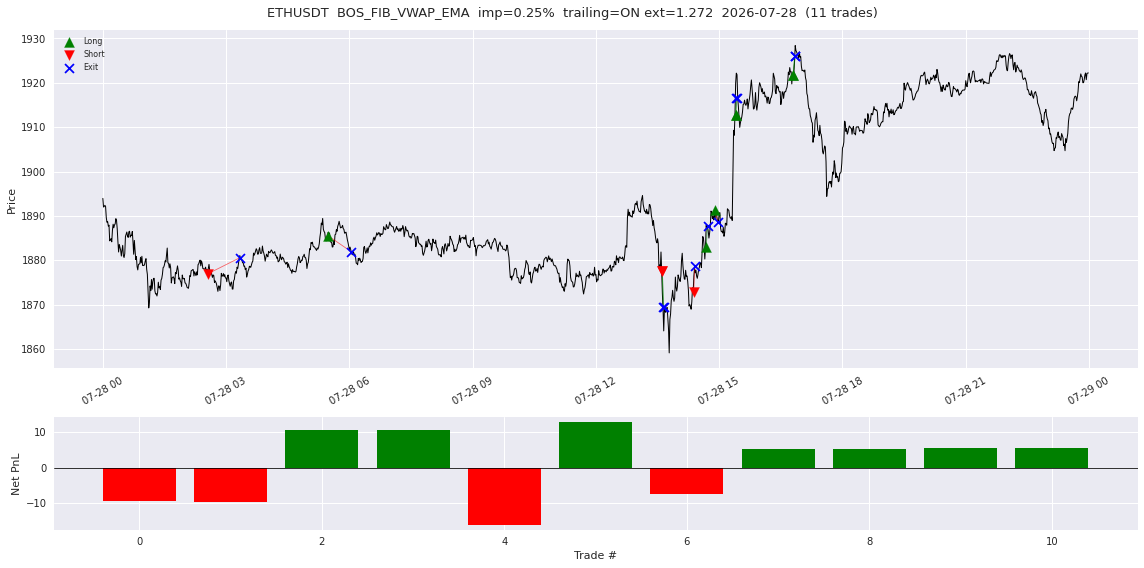

,entry_time,side,entry_price,exit_price,exit_reason,gross_pnl,net_pnl
0,2026-07-28 02:34:00+00:00,SHORT,1877.00,1880.57130,stop_loss,-9.511673,-9.511673
1,2026-07-28 05:29:00+00:00,LONG,1885.51,1881.88870,stop_loss,-9.605758,-9.605758
2,2026-07-28 13:37:00+00:00,SHORT,1877.60,1869.53736,partial_target,10.710875,10.710875
3,2026-07-28 13:37:00+00:00,SHORT,1877.60,1869.53736,target,10.710875,10.710875
4,2026-07-28 14:23:00+00:00,SHORT,1872.79,1878.81130,stop_loss,-16.058865,-16.058865
5,2026-07-28 14:41:00+00:00,LONG,1882.92,1887.73000,trail_stop,12.789912,12.789912
6,2026-07-28 14:54:00+00:00,LONG,1891.33,1888.51870,stop_loss,-7.435287,-7.435287
7,2026-07-28 15:24:00+00:00,LONG,1912.69,1916.59736,partial_target,5.114267,5.114267
8,2026-07-28 15:24:00+00:00,LONG,1912.69,1916.59736,target,5.114267,5.114267
9,2026-07-28 16:48:00+00:00,LONG,1921.87,1926.07576,partial_target,5.476893,5.476893


In [11]:
INSPECT_SYM      = list(results.keys())[0] if results else None
INSPECT_VARIANT  = 'VWAP_EMA'      # BASE / VWAP / EMA / VWAP_EMA
INSPECT_IMP_PCT  = 0.25            # one of IMPULSE_PCT_SWEEP values
INSPECT_TARGET_EXT = 1.272         # one of TARGET_EXT_SWEEP values
INSPECT_DATE     = None            # e.g. '2026-04-01'  (None = worst-PnL day)


def plot_trade_day(sym, variant, imp_pct, target_ext, trade_date=None):
    r = results.get(sym, {}).get(variant, {}).get(imp_pct, {}).get(target_ext)
    if not r:
        print(f'No result for {sym}/{variant}/imp={imp_pct}/ext={target_ext}'); return
    t = _prep(r)
    if t.empty:
        print(f'No trades for {sym}/{variant}/imp={imp_pct}/ext={target_ext}'); return

    if trade_date is None:
        trade_date = t.loc[t['net_pnl'].abs().idxmax(), 'trade_date']

    mkt   = r['_market_data']
    dsym  = mkt['symbol'].iloc[0]
    day_d = mkt[(mkt['symbol'] == dsym) & (mkt['trade_date'] == str(trade_date))]
    day_t = t[t['trade_date'] == pd.Timestamp(trade_date).date()]

    if day_d.empty:
        print(f'No market data for {sym} on {trade_date}'); return

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [3, 1]})
    trail_label = f'trailing=ON ext={target_ext}' if USE_TRAILING_STOP else f'trailing=OFF ext={target_ext}'
    fig.suptitle(f'{sym}  BOS_FIB_{variant}  imp={imp_pct}%  {trail_label}  {trade_date}  ({len(day_t)} trades)', fontsize=13)

    ax = axes[0]
    ax.plot(day_d['timestamp'], day_d['close'], color='black', linewidth=1.0)
    longs  = day_t[day_t['side'] == 'LONG']
    shorts = day_t[day_t['side'] == 'SHORT']
    ax.scatter(longs['entry_time'],  longs['entry_price'],  marker='^', s=100, color='green', zorder=5, label='Long')
    ax.scatter(shorts['entry_time'], shorts['entry_price'], marker='v', s=100, color='red',   zorder=5, label='Short')
    ax.scatter(day_t['exit_time'],   day_t['exit_price'],   marker='x', s=80,  color='blue',  zorder=5, label='Exit')
    for _, tr in day_t.iterrows():
        color = 'green' if tr['net_pnl'] > 0 else (
            'orange' if tr['exit_reason'] in ('trail_stop', 'partial_target') else 'red'
        )
        ax.plot([tr['entry_time'], tr['exit_time']], [tr['entry_price'], tr['exit_price']],
                color=color, linewidth=0.8, alpha=0.6)
    ax.set_ylabel('Price'); ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

    axes[1].bar(range(len(day_t)), day_t['net_pnl'],
                color=['green' if v > 0 else 'red' for v in day_t['net_pnl']])
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Trade #'); axes[1].set_ylabel('Net PnL')
    plt.tight_layout(); plt.show()
    display(day_t[['entry_time','side','entry_price','exit_price','exit_reason','gross_pnl','net_pnl']])


if INSPECT_SYM:
    plot_trade_day(INSPECT_SYM, INSPECT_VARIANT, INSPECT_IMP_PCT, INSPECT_TARGET_EXT, INSPECT_DATE)


## Signal & Hourly Detail (per symbol)

In [12]:
for sym, variants in results.items():
    print(f"\n{'='*70}")
    print(f"{sym}")
    for variant, imps in variants.items():
        for imp_pct, exts in imps.items():
            for target_ext, r in exts.items():
#                 import pdb; pdb.set_trace()
                if target_ext == 1.618 and variant == 'BASE' and imp_pct == 0.25:
                    sigs = r['selected_strategy_signals']
                    print(f"\n  ── BOS_FIB_{variant}  imp={imp_pct}%  ext={target_ext}  ({len(sigs)} signals) ──")
                    display(strategy_summary(r['trades']))
                    display(hourly_summary(r['trades']))



ETHUSDT

  ── BOS_FIB_BASE  imp=0.25%  ext=1.618  (27 signals) ──


,strategy_name,trades,gross_pnl,net_pnl,win_rate
0,BOS_FIB_BASE,27,24.432504,24.432504,51.851852


,entry_hour,trades,gross_pnl,net_pnl,win_rate
0,00:00,1,14.593650,14.593650,100.000000
1,01:00,2,26.204635,26.204635,100.000000
2,02:00,2,-24.062348,-24.062348,0.000000
3,03:00,1,2.699051,2.699051,100.000000
4,05:00,1,-9.605758,-9.605758,0.000000
5,06:00,1,-10.536312,-10.536312,0.000000
6,07:00,1,5.414162,5.414162,100.000000
7,08:00,1,-6.214207,-6.214207,0.000000
8,10:00,1,15.478994,15.478994,100.000000
9,11:00,1,-9.773748,-9.773748,0.000000



SOLUSDT

  ── BOS_FIB_BASE  imp=0.25%  ext=1.618  (37 signals) ──


,strategy_name,trades,gross_pnl,net_pnl,win_rate
0,BOS_FIB_BASE,30,75.837348,75.837348,63.333333


,entry_hour,trades,gross_pnl,net_pnl,win_rate
0,00:00,2,31.748024,31.748024,100.000000
1,01:00,1,3.413017,3.413017,100.000000
2,02:00,1,38.024776,38.024776,100.000000
3,03:00,1,8.186254,8.186254,100.000000
4,04:00,1,-19.844012,-19.844012,0.000000
5,05:00,1,-14.320524,-14.320524,0.000000
6,06:00,1,-12.274695,-12.274695,0.000000
7,08:00,2,-10.909352,-10.909352,0.000000
8,11:00,1,-10.927266,-10.927266,0.000000
9,13:00,3,17.733451,17.733451,66.666667
